# D11 Calculation Pathway Effects

Analyze how `D11` changes across calculation pathways while holding the observed ECTP slab fixed. 

In [42]:
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebook_utils import (
    create_ectp_slabs,
    extract_d11,
    finite_percentile,
    finite_positive,
    hess_rcparams,
    load_pits,
    pathway_key,
    prepare_spread_rank_table,
    slab_attribute_record,
)
from paper_figure_utils import (
    format_method_path,
)
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.execution.config import ExecutionConfig
from snowpyt_mechparams.graph import default_graph
from snowpyt_mechparams.pathway import find_parameterizations

hess_rcparams()

TOP_N = 8

## Load Data and Enumerate D11 Pathways

Use the same ECTP slab definition as the slab-weight input analysis: Slab is the set of layers above the ECTP layer of propagation

In [43]:
pits = load_pits()
ectp_slabs = create_ectp_slabs(pits)
total_slabs = len(ectp_slabs)

pathways = find_parameterizations(default_graph, default_graph.get_node('D11'))
engine = ExecutionEngine()
config = ExecutionConfig(include_method_uncertainty=False) # input uncertainty only

print(f'Loaded {len(pits):,} pits and {total_slabs:,} ECTP slabs')
print(f'D11 pathways: {len(pathways)}')

Loaded 50,278 pits and 14,776 ECTP slabs
D11 pathways: 32


## Execute D11 Pathways

Store one row per slab-pathway attempt. Failed attempts remain in `d11_results` with `NaN` values so coverage can be computed directly from the same table.

In [44]:
records = []

for slab_index, slab in enumerate(ectp_slabs):
    slab_attrs = slab_attribute_record(slab_index, slab)
    results = engine.execute_all(slab, 'D11', config=config, pathways=pathways)

    for pathway_result in results.pathways.values():
        methods = pathway_result.methods_used
        d11_nominal, d11_std = extract_d11(pathway_result)
        d11_success = finite_positive(d11_nominal)

        records.append(
            {
                **slab_attrs,
                'pathway': pathway_key(methods),
                'pathway_description': pathway_result.pathway_description,
                'density_method': methods.get('density', 'data_flow'),
                'emod_method': methods.get('elastic_modulus', 'unknown'),
                'nu_method': methods.get('poissons_ratio', 'unknown'),
                'pathway_result_success': pathway_result.success,
                'success': d11_success,
                'D11_nominal': d11_nominal if d11_success else math.nan,
                'D11_std': d11_std if d11_success else math.nan,
                'D11_rel_uncertainty': d11_std / abs(d11_nominal) if d11_success else math.nan,
            }
        )

d11_results = pd.DataFrame(records)
d11_success = d11_results[d11_results['success']].copy()

print(f'Pathway attempts: {len(d11_results):,}')
print(f'Successful D11 calculations: {len(d11_success):,}')
print(f'Slabs with at least one successful D11 value: {d11_success["slab_index"].nunique():,}')
#d11_results.head()

Pathway attempts: 472,832
Successful D11 calculations: 8,858
Slabs with at least one successful D11 value: 823


## Top 8 Coverage Pathways

Rank pathways by successful ECTP slab coverage. 

In [45]:
pathway_coverage = (
    d11_results.groupby(['pathway', 'density_method', 'emod_method', 'nu_method'])
    .agg(
        successful_slabs=('success', 'sum'),
        attempted_slabs=('success', 'count'),
    )
    .reset_index()
    .sort_values(['successful_slabs', 'pathway'], ascending=[False, True])
)
pathway_coverage['coverage_percent'] = 100.0 * pathway_coverage['successful_slabs'] / total_slabs

top_pathways = pathway_coverage.head(TOP_N)['pathway'].tolist()
coverage_table = pd.DataFrame(
    {
        'Pathway': [format_method_path(*pathway.split(' -> ')) for pathway in top_pathways],
        'Successful slabs': pathway_coverage.head(TOP_N)['successful_slabs'].map(lambda value: f'{int(value):,}'),
        'Coverage (%)': pathway_coverage.head(TOP_N)['coverage_percent'].map(lambda value: f'{value:.1f}'),
    }
)

coverage_table

# Update index to be ranking
coverage_table.index = coverage_table.index.get_indexer(coverage_table.index)
coverage_table.index.name = 'Rank'
coverage_table


,Pathway,Successful slabs,Coverage (%)
Rank,,,
0,Kim and Jamieson Table 2 -> Schottner et al. (...,743,5.0
1,Kim and Jamieson Table 2 -> Wautier et al. (20...,743,5.0
2,Geldsetzer and Jamieson (2000) -> Schottner et...,740,5.0
3,Geldsetzer and Jamieson (2000) -> Wautier et a...,740,5.0
4,Geldsetzer and Jamieson (2000) -> Kochle and S...,733,5.0
5,Kim and Jamieson Table 2 -> Kochle and Schneeb...,634,4.3
6,Kim and Jamieson Table 2 -> Bergfeld et al. (2...,498,3.4
7,Geldsetzer and Jamieson (2000) -> Bergfeld et ...,475,3.2


## Top-8 Slab Subset

Keep only slabs where all top-8 pathways produced finite, positive D11 values.

In [46]:
top8_success = d11_success[d11_success['pathway'].isin(top_pathways)].copy()
common_counts = top8_success.groupby('slab_index')['pathway'].nunique()
common_slab_indices = common_counts[common_counts == TOP_N].index

d11_common = top8_success[top8_success['slab_index'].isin(common_slab_indices)].copy()
d11_common['pathway'] = pd.Categorical(d11_common['pathway'], categories=top_pathways, ordered=True)
d11_common = d11_common.sort_values(['pathway', 'slab_index'])

d11_wide = d11_common.pivot(
    index=['slab_index', 'slab_id', 'pit_id'],
    columns='pathway',
    values='D11_nominal',
).reindex(columns=top_pathways)

print(f'Top-8 pathways: {TOP_N}')
print(f'Slabs successful for all top-8 pathways: {len(common_slab_indices):,}')

d11_wide.head()


Top-8 pathways: 8
Slabs successful for all top-8 pathways: 412


,,pathway,kim_jamieson_table2 -> schottner -> kochle,kim_jamieson_table2 -> wautier -> kochle,geldsetzer -> schottner -> kochle,geldsetzer -> wautier -> kochle,geldsetzer -> kochle -> kochle,kim_jamieson_table2 -> kochle -> kochle,kim_jamieson_table2 -> bergfeld -> kochle,geldsetzer -> bergfeld -> kochle
slab_index,slab_id,pit_id,,,,,,,,
98,1036_slab_0,1036,1.033784e+05,3.897811e+06,9.853946e+04,3.803908e+06,1.058172e+06,1.171239e+06,2.183333e+05,2.085478e+05
141,1057_slab_0,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07
142,1057_slab_1,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07
143,1057_slab_2,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07
144,1057_slab_3,1057,3.364213e+07,1.037104e+09,3.518988e+07,1.061108e+09,2.822266e+08,2.740997e+08,6.979665e+07,7.286510e+07


Middle 95% D11 filter: 4.084e+04 to 3.128e+09


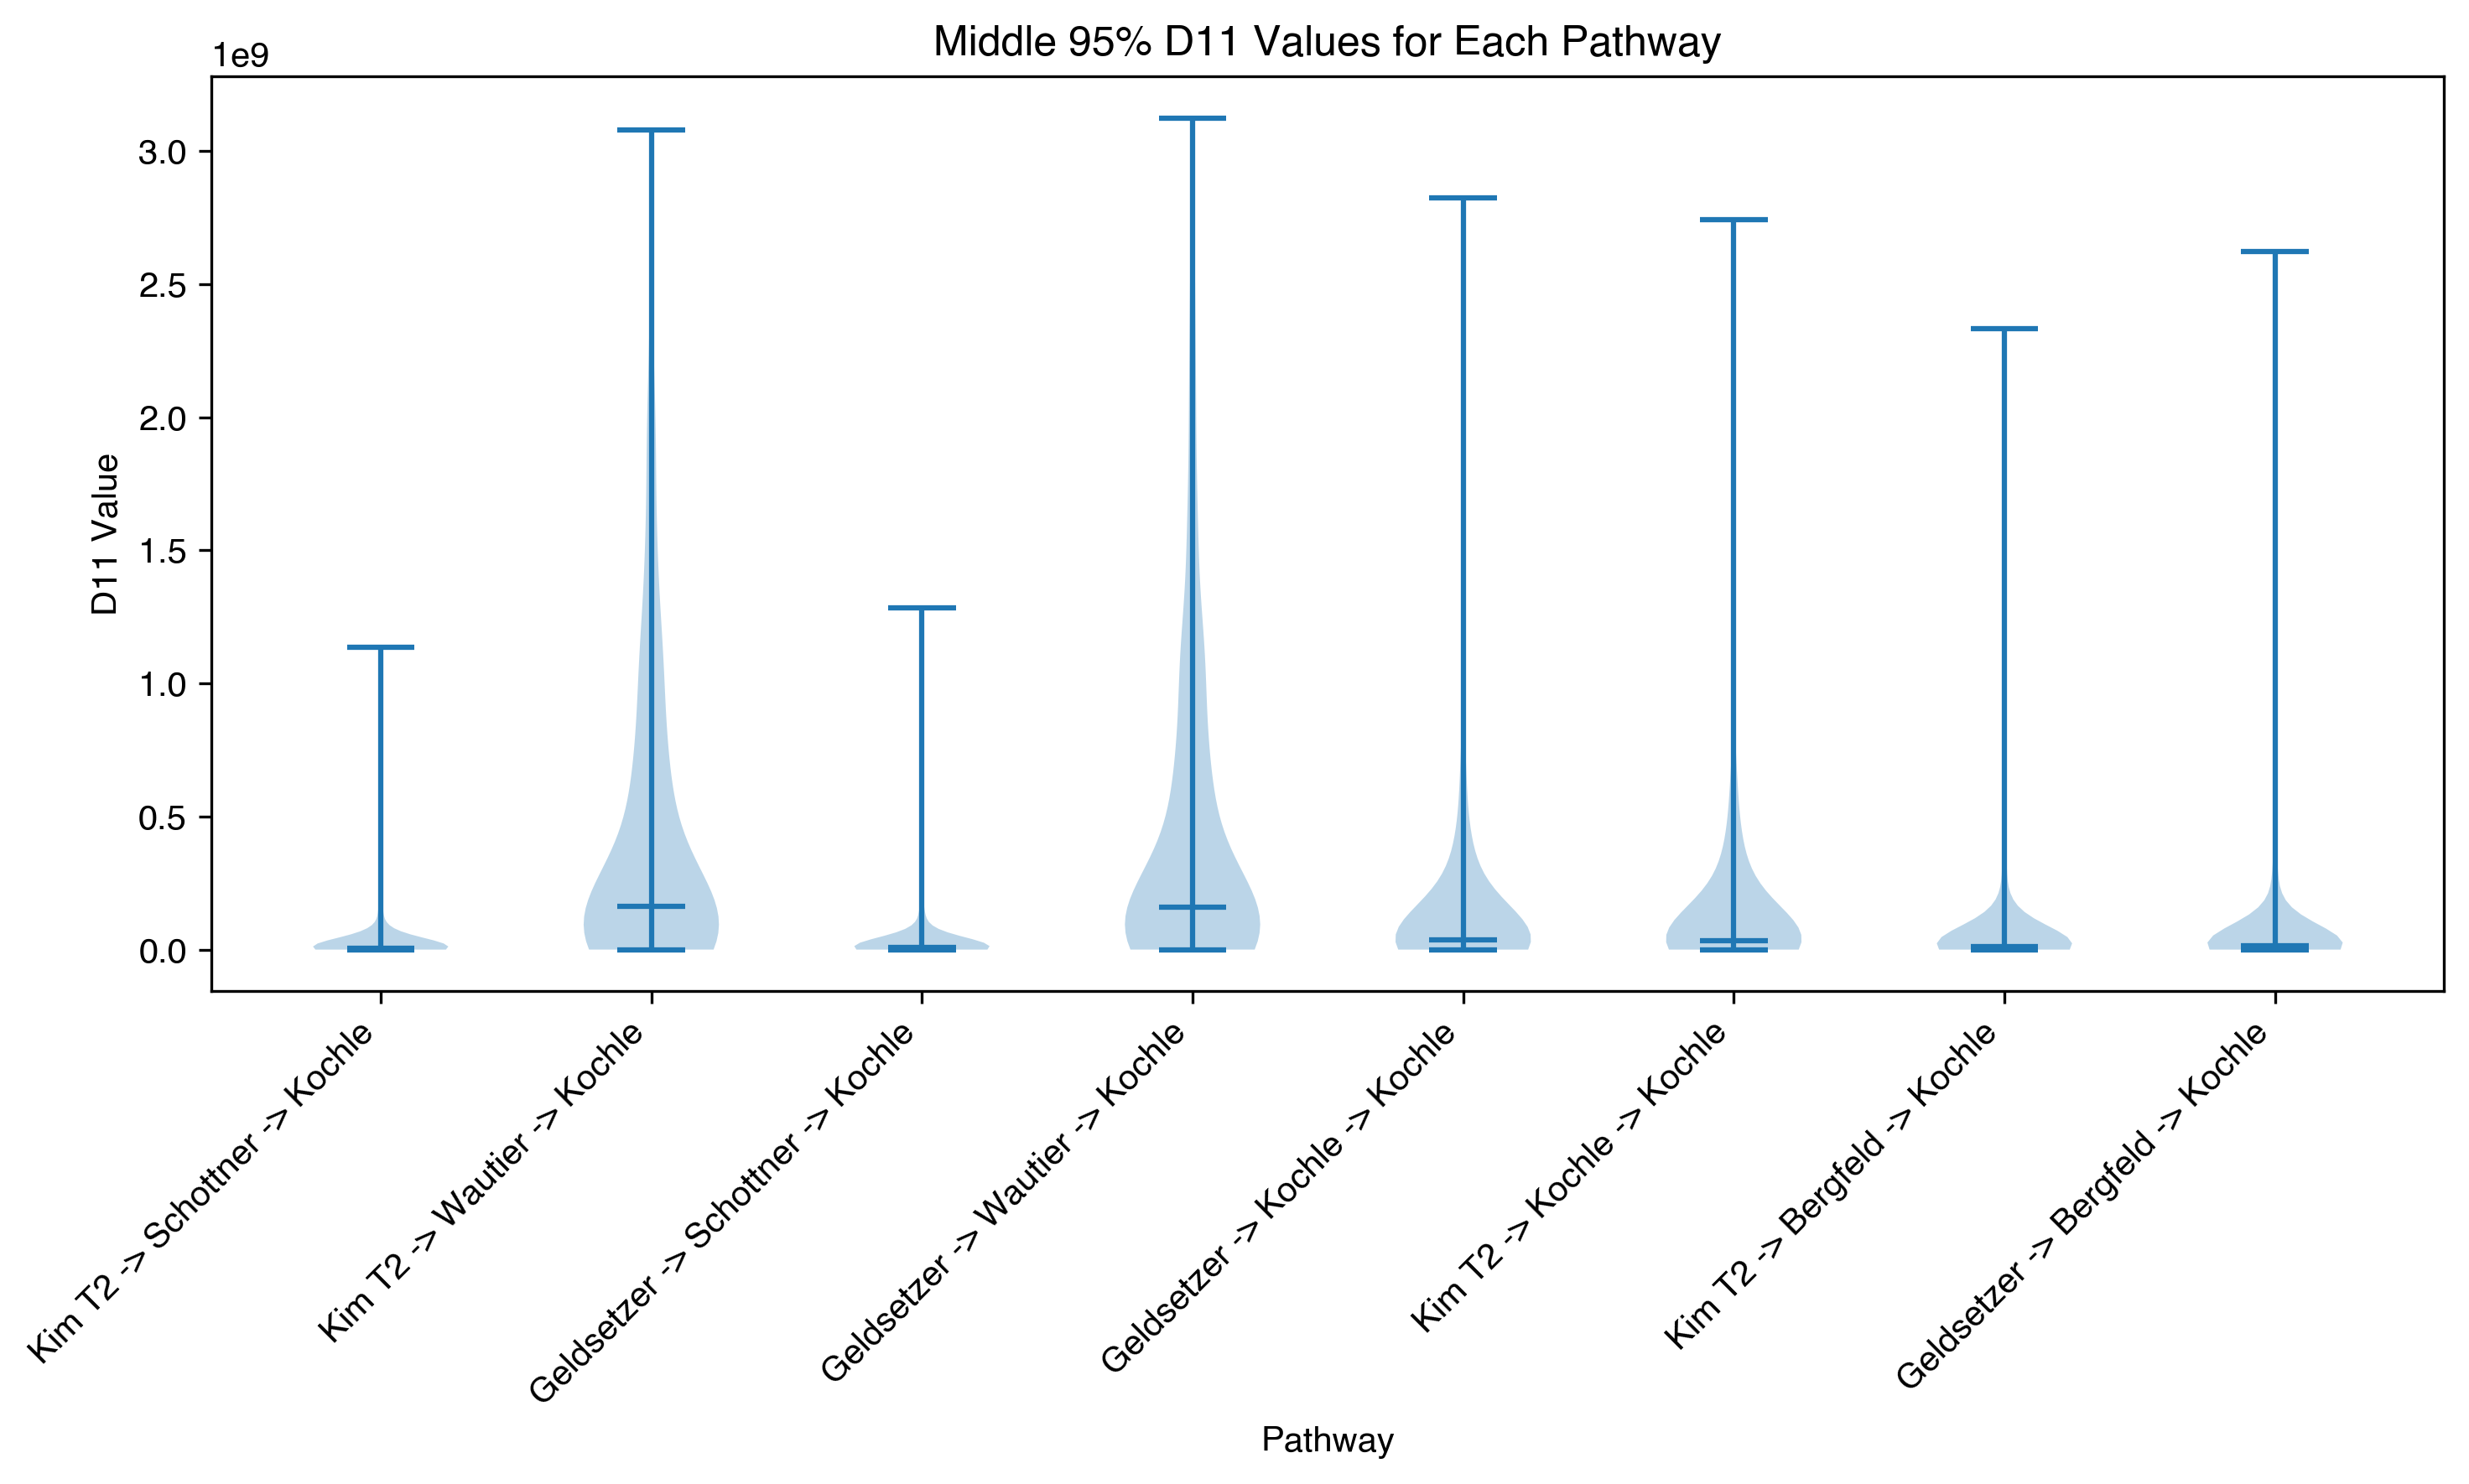

In [47]:
# Violin plot of the middle 95% of D11 values by pathway
d11_lower = finite_percentile(d11_wide.to_numpy().ravel(), 2.5)
d11_upper = finite_percentile(d11_wide.to_numpy().ravel(), 97.5)
d11_violin = d11_wide.where((d11_wide >= d11_lower) & (d11_wide <= d11_upper))

print(f'Middle 95% D11 filter: {d11_lower:.3e} to {d11_upper:.3e}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.violinplot([d11_violin[pathway].dropna() for pathway in top_pathways], showmedians=True)
ax.set_title('Middle 95% D11 Values for Each Pathway')
ax.set_xlabel('Pathway')
ax.set_ylabel('D11 Value')
ax.set_xticks(range(1, len(top_pathways) + 1))
ax.set_xticklabels(
    [format_method_path(*pathway.split(' -> '), short=True) for pathway in top_pathways],
    rotation=45,
    ha='right',
)
fig.tight_layout()
plt.show()


## Random Slab D11 Pathway Uncertainty

Plot D11 values and input uncertainty for 10 randomly selected slabs with complete top-8 pathway coverage.

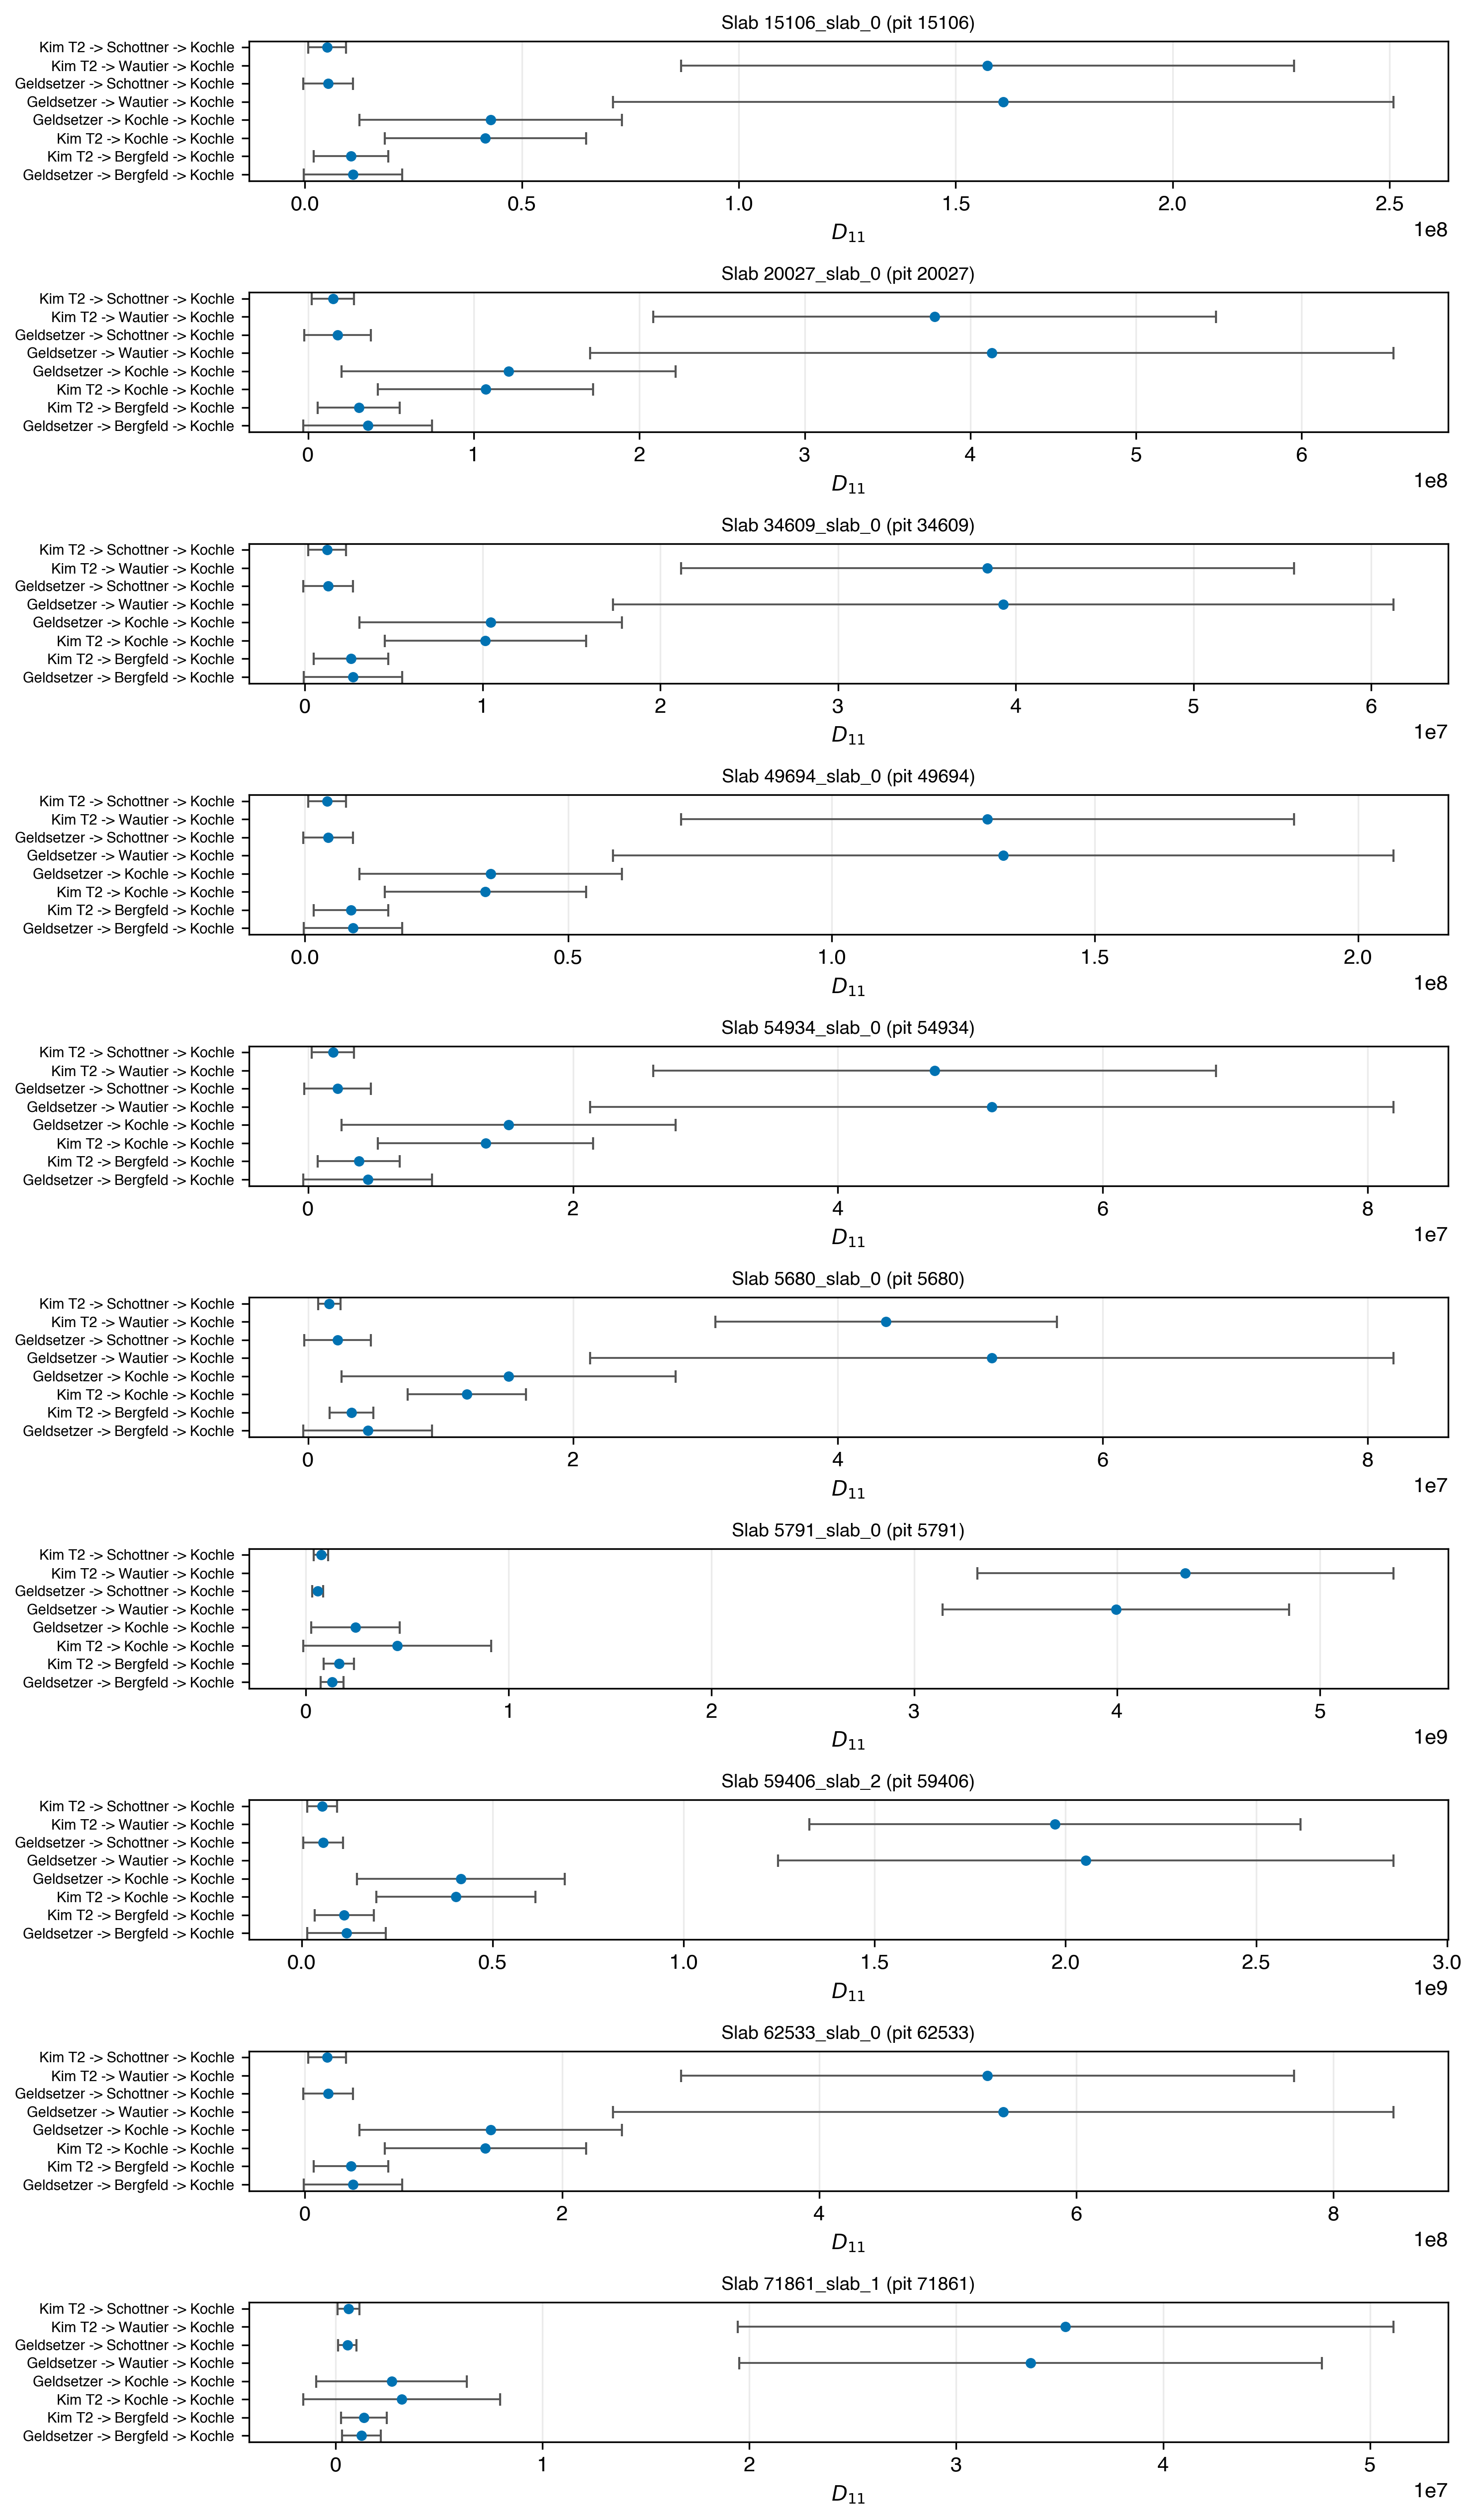

In [48]:
random_slabs = (
    d11_common[['slab_index', 'slab_id', 'pit_id']]
    .drop_duplicates()
    .sample(n=min(10, len(common_slab_indices)), random_state=42)
    .sort_values('slab_index')
)
random_slab_indices = random_slabs['slab_index'].tolist()
random_d11 = d11_common[d11_common['slab_index'].isin(random_slab_indices)].copy()
random_d11['pathway'] = pd.Categorical(random_d11['pathway'], categories=top_pathways, ordered=True)

fig, axes = plt.subplots(
    len(random_slabs),
    1,
    figsize=(10, 1.7 * len(random_slabs)),
    sharex=False,
)
if len(random_slabs) == 1:
    axes = [axes]

pathway_labels = [format_method_path(*pathway.split(' -> '), short=True) for pathway in top_pathways]

for ax, slab in zip(axes, random_slabs.itertuples(index=False), strict=True):
    slab_rows = random_d11[random_d11['slab_index'] == slab.slab_index].sort_values('pathway')
    y_positions = np.arange(len(slab_rows))
    d11_uncertainty = np.nan_to_num(
        slab_rows['D11_std'].to_numpy(dtype=float),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    d11_uncertainty = np.clip(d11_uncertainty, 0.0, None)

    ax.errorbar(
        slab_rows['D11_nominal'],
        y_positions,
        xerr=d11_uncertainty,
        fmt='o',
        capsize=3,
        markersize=4,
        color='#0072B2',
        ecolor='#555555',
        elinewidth=0.9,
    )
    ax.set_yticks(y_positions)
    ax.set_yticklabels(pathway_labels, fontsize=7)
    ax.invert_yaxis()
    ax.set_title(f'Slab {slab.slab_id} (pit {slab.pit_id})', fontsize=9)
    ax.set_xlabel(r'$D_{11}$')
    ax.grid(axis='x', alpha=0.25)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))

fig.tight_layout()
plt.show()